In [4]:
import os
import sys
import time
import copy

import json

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [2]:
# NOTE: if target_vocab_size < num(unique_characters) it returns character-level tokenizer!
target_vocab_size = 8192

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
trainer = BpeTrainer(vocab_size=target_vocab_size, special_tokens=["[UNK]", "<eos>"])

# to cap the tokens to entire words
tokenizer.pre_tokenizer = Whitespace()

In [3]:
iterator = []

for split in ['train', 'valid']:

    txt_file_path = f"tinystories/TinyStoriesV2-GPT4-{split}.txt"

    # Read the entire file
    with open(txt_file_path, "r", encoding="utf-8") as f:
        data = f.read()
    print(f'{len(data)} {split} characters')

    # Split into individual stories
    stories = data.split("<|endoftext|>")

    # Filter out empty entries
    iterator += [story.strip() for story in stories if story.strip()]

    print(f"Loaded {len(stories)} {split} stories.")
    print("First story:\n", stories[0])

2226845522 train characters
Loaded 2717701 train stories.
First story:
 Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, “Wow, that is a really amazing vase! Can I buy it?” 
The shopkeeper smiled and said, “Of course you can. You can take it home and show all your friends how amazing it is!”
So Ben took the vase home and he was so proud of it! He called his friends over and showed them the amazing vase. All his friends thought the vase was beautiful and couldn't believe how lucky Ben was. 
And that's how Ben found an amazing vase in the store!

22493131 valid characters
Loaded 27630 valid stories.
First story:
 Once upon a time, in a warm and sunny place, there was a big pit. A little boy named Tom liked to play near the pit. One day, To

In [4]:
# Train tokenizer from list of text pieces
tokenizer.train_from_iterator(iterator, trainer=trainer)

In [5]:
example = tokenizer.encode(stories[0])
print(example.tokens)
print(example.ids)

['Once', 'upon', 'a', 'time', ',', 'in', 'a', 'warm', 'and', 'sunny', 'place', ',', 'there', 'was', 'a', 'big', 'pit', '.', 'A', 'little', 'boy', 'named', 'Tom', 'liked', 'to', 'play', 'near', 'the', 'pit', '.', 'One', 'day', ',', 'Tom', 'lost', 'his', 'red', 'ball', '.', 'He', 'was', 'very', 'sad', '.', 'Tom', 'asked', 'his', 'friend', ',', 'Sam', ',', 'to', 'help', 'him', 'search', 'for', 'the', 'ball', '.', 'They', 'looked', 'high', 'and', 'low', ',', 'but', 'they', 'could', 'not', 'find', 'the', 'ball', '.', 'Tom', 'said', ',', '"', 'I', 'think', 'my', 'ball', 'fell', 'into', 'the', 'pit', '."', 'Sam', 'and', 'Tom', 'went', 'close', 'to', 'the', 'pit', '.', 'They', 'were', 'scared', ',', 'but', 'they', 'wanted', 'to', 'find', 'the', 'red', 'ball', '.', 'They', 'looked', 'into', 'the', 'pit', ',', 'but', 'it', 'was', 'too', 'dark', 'to', 'see', '.', 'Tom', 'said', ',', '"', 'We', 'must', 'go', 'in', 'and', 'search', 'for', 'my', 'ball', '."', 'They', 'went', 'into', 'the', 'pit', 't

In [6]:
vocab = tokenizer.get_vocab()
i_to_t = {i:t for t, i in vocab.items()}

print(vocab['<eos>'])
print(len(vocab))

# save vocabulary as .json
tokenizer.save(f"tinystories/tinystories.BPE{target_vocab_size}.tokenizer.json")

{1028: 'dif', 3425: 'five', 1320: 'clapped', 6004: 'wishing', 5682: 'workers', 6786: 'cleaner', 5626: 'activ', 2017: 'smooth', 806: 'blue', 1761: 'course', 2976: 'engine', 7401: 'springing', 833: 'great', 1709: 'herself', 4618: 'worth', 683: 'ell', 4869: 'Rocky', 970: 'expl', 1330: 'job', 2316: 'cand', 3814: 'vehicle', 6499: 'Nobody', 6288: 'tram', 7130: 'quie', 7669: 'Jas', 5508: 'flags', 2901: 'pige', 17: '0', 3115: 'thief', 6405: 'everybody', 4481: 'luck', 5686: 'stern', 3546: 'tion', 5567: 'screaming', 3781: 'pinch', 2485: 'est', 6931: 'dump', 3376: 'cable', 3: '"', 4317: 'exerc', 6141: 'tapped', 4552: 'chores', 5858: 'jackets', 5351: 'cub', 3126: 'eventually', 7387: 'vented', 323: 'ould', 931: 'two', 5777: 'prayer', 1912: 'princess', 4189: 'ude', 7745: 'hisses', 7869: 'chews', 1668: 'basket', 2857: 'hurts', 2235: 'boring', 3802: 'sandwiches', 3935: 'uage', 5812: 'tables', 6627: 'Davey', 2929: 'ruined', 3304: 'stranger', 3463: 'dess', 4418: 'palm', 6022: 'avocados', 5572: 'acti', 2

In [7]:
# save vocabulary as .json
tokenizer.save(f"tinystories/tinystories.BPE{target_vocab_size}.tokenizer.json")

## TOKENIZE TRAIN SPLIT

In [8]:
split = 'train'
txt_file_path = f"tinystories/TinyStoriesV2-GPT4-{split}.txt"

# Read the entire file
with open(txt_file_path, "r", encoding="utf-8") as f:
    data = f.read()
print(f'{len(data)} {split} characters')

# Split into individual stories
stories = data.split("<|endoftext|>")

# Filter out empty entries
stories = [story.strip() for story in stories if story.strip()]

print(f"Loaded {len(stories)} {split} stories.")
print("First story:\n", stories[0])

2226845522 train characters
Loaded 2717495 train stories.
First story:
 Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, “Wow, that is a really amazing vase! Can I buy it?” 
The shopkeeper smiled and said, “Of course you can. You can take it home and show all your friends how amazing it is!”
So Ben took the vase home and he was so proud of it! He called his friends over and showed them the amazing vase. All his friends thought the vase was beautiful and couldn't believe how lucky Ben was. 
And that's how Ben found an amazing vase in the store!


In [9]:
lengths = []
tokenised = []
for story in stories:
    output = tokenizer.encode(story)
    tokenised += output.ids + [1]   # 1 is the id of <eos> token
    lengths.append(len(output))

In [5]:
import numpy as np
import matplotlib.pyplot as plt

print('Number of tokens: ', len(tokenised))
print('min/max story length: ', min(lengths), max(lengths))
print('average story length: ', sum(lengths)/len(lengths))

fig, ax = plt.subplots( 1, 1, figsize=(10,5))

hist, bins = np.histogram(np.array(lengths), bins='fd', density=True)
centres = []
for k in range(len(hist)):
    point = (bins[k+1] + bins[k]) * 0.5
    centres.append(point)
ax.plot( centres, hist, 'C0')

ax.set_xscale('log')
ax.set_yscale('log')

NameError: name 'tokenised' is not defined

In [11]:
np.save(f"tinystories/tinystories.BPE{target_vocab_size}.train.npy", np.array(tokenised, dtype=np.int32))

## TOKENISE VALIDATION SPLIT

In [14]:
split = 'valid'
txt_file_path = f"tinystories/TinyStoriesV2-GPT4-{split}.txt"

# Read the entire file
with open(txt_file_path, "r", encoding="utf-8") as f:
    data = f.read()
print(f'{len(data)} {split} characters')

# Split into individual stories
stories = data.split("<|endoftext|>")

# Filter out empty entries
stories = [story.strip() for story in stories if story.strip()]

print(f"Loaded {len(stories)} {split} stories.")
print("First story:\n", stories[0])

22493131 valid characters
Loaded 27629 valid stories.
First story:
 Once upon a time, in a warm and sunny place, there was a big pit. A little boy named Tom liked to play near the pit. One day, Tom lost his red ball. He was very sad.
Tom asked his friend, Sam, to help him search for the ball. They looked high and low, but they could not find the ball. Tom said, "I think my ball fell into the pit."
Sam and Tom went close to the pit. They were scared, but they wanted to find the red ball. They looked into the pit, but it was too dark to see. Tom said, "We must go in and search for my ball."
They went into the pit to search. It was dark and scary. They could not find the ball. They tried to get out, but the pit was too deep. Tom and Sam were stuck in the pit. They called for help, but no one could hear them. They were sad and scared, and they never got out of the pit.


In [15]:
lengths = []
tokenised = []
for story in stories:
    output = tokenizer.encode(story)
    tokenised += output.ids + [1]   # 1 is the id of <eos> token
    lengths.append(len(output))

Number of tokens:  5343921
min/max story length:  58 1092
average story length:  192.41709797676356


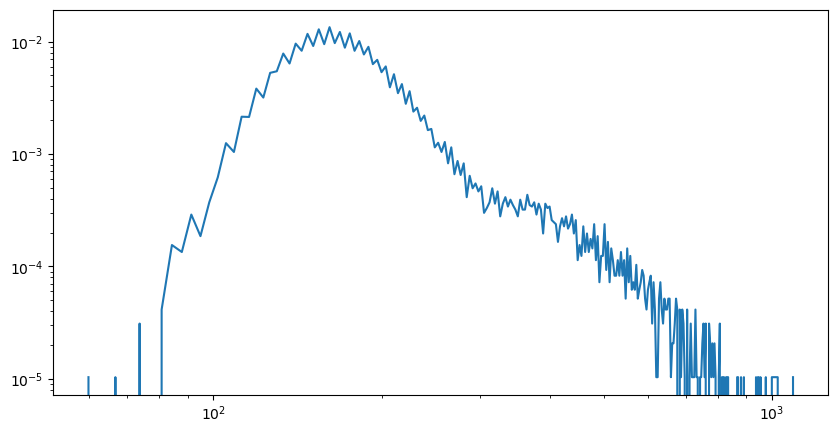

In [16]:
print('Number of tokens: ', len(tokenised))
print('min/max story length: ', min(lengths), max(lengths))
print('average story length: ', sum(lengths)/len(lengths))

fig, ax = plt.subplots( 1, 1, figsize=(10,5))

hist, bins = np.histogram(np.array(lengths), bins='fd', density=True)
centres = []
for k in range(len(hist)):
    point = (bins[k+1] + bins[k]) * 0.5
    centres.append(point)
ax.plot( centres, hist, 'C0')

ax.set_xscale('log')
ax.set_yscale('log')

In [17]:
np.save(f"tinystories/tinystories.BPE{target_vocab_size}.valid.npy", np.array(tokenised, dtype=np.int32))

In [25]:
tokenizer_file = f"tinystories/tinystories.BPE{target_vocab_size}.tokenizer.json"
tokenizer = Tokenizer.from_file(f"tinystories/tinystories.BPE{target_vocab_size}.tokenizer.json")

data_dict = {
    'vocab_size': tokenizer.get_vocab_size(),
    'eos_token_id': tokenizer.token_to_id("<eos>"),
    'unk_token_id': tokenizer.token_to_id("[UNK]"),
    'tokenizer_file': tokenizer_file,
    'train_size': 529209187,
    'valid_size': 5343921,
}

with open(f"tinystories/tinystories.BPE{target_vocab_size}.meta.json", "w") as f:
    json.dump(data_dict, f, indent=2)

## LOAD

In [8]:
loaded = np.load(f"tinystories/tinystories.BPE{target_vocab_size}.valid.npy")
print(len(loaded))
print(loaded[:128])

5343921
[ 366  371   65  331   13  228   65  910  227 1016  802   13  338  236
   65  286 3187   15   34  326  420  340  330  453  226  269  718  224
 3187   15  322  267   13  330  907  266  481  400   15  259  236  289
  417   15  330  463  266  298   13  440   13  226  370  405 2230  318
  224  400   15  255  425  785  227  534   13  345  301  397  304  486
  224  400   15  330  270   13    3   42  993  358  400  926  611  224
 3187  335  440  227  330  365 1205  226  224 3187   15  255  342  516
   13  345  301  344  226  486  224  481  400   15  255  425  611  224
 3187   13  345  230  236  355 1113  226  460   15  330  270   13    3
  571 1247]


In [10]:
with open(f"tinystories/tinystories.BPE{target_vocab_size}.meta.json", 'r') as f:
    tokenizer_meta = json.load(f)
print(tokenizer_meta['vocab_size'])
print(tokenizer_meta['eos_token_id'])
print(tokenizer_meta['unk_token_id'])

tokenizer_file = tokenizer_meta['tokenizer_file']
tokenizer = Tokenizer.from_file(tokenizer_file)
print(tokenizer)

8192
1
0


In [11]:
target_vocab_size = 8192

loaded = np.load(f"tinystories/tinystories.BPE{target_vocab_size}.train.npy")
print(len(loaded))

loaded_text = tokenizer.decode(loaded[:1024])
print(loaded_text)

529209187
Once upon a time there was a little boy named Ben . Ben loved to explore the world around him . He saw many amazing things , like beautiful va ses that were on display in a store . One day , Ben was walking through the store when he came across a very special vase . When Ben saw it he was amazed ! He said , “ Wow , that is a really amazing vase ! Can I buy it ?” The shopkeeper smiled and said , “ Of course you can . You can take it home and show all your friends how amazing it is !” So Ben took the vase home and he was so proud of it ! He called his friends over and showed them the amazing vase . All his friends thought the vase was beautiful and couldn ' t believe how lucky Ben was . And that ' s how Ben found an amazing vase in the store ! Once upon a time , there was a reliable otter named Ollie . He lived in a river with his family . They all loved to play and swim together . One day , Ollie ' s mom said , " Ollie , hurry and get some fish for dinner !" Ollie swam fast to